In [2]:
# %%
import matplotlib.pyplot as plt
import gc
import os
import shutil
import sys
import time
import warnings
from functools import partial
import torch.distributed as tdist
import torch
from PIL import Image
from torch.utils.data import DataLoader
from utils.dynamic_resolution import dynamic_resolution_h_w, h_div_w_templates
import numpy as np
import dist
from utils import arg_util, misc
from utils.data import build_dataset
from utils.data_sampler import DistInfiniteBatchSampler, EvalDistributedSampler
from utils.misc import auto_resume
import math
from models import SRVAR, VQVAE, build_vae_srvar

args: arg_util.Args = arg_util.Args()
# args.data = "./data/df2k_ost/GT_resized"
# args.data = "./data/DIV2K_train_HR"
# args.data = "./data/train"
# args.data = "./data/brats_256_t1_new/train"
args.batch_size = 1
args.fp16=1
args.alng = 1e-3
args.wpe = 0.1
args.pn = "1M"
args.rope2d_normalized_by_hw = 2
args.rope2d_each_sa_layer = 1
args.enable_checkpointing = "full-block"
args.tlen = 1024
args.device = "cuda"

args.Ct5 = 32
args.vocab_size = 4096
args.data_path = "./data/brats_256_t1_2021_pair_4x/"
tot = 10
# ckpt_path_srvar = f"ckpt_save/2/2_ar-ckpt-best.pth"
ckpt_path_srvar = f"local_output/ar-ckpt-last.pth"


args.seed = 666
args.seed_everything(False)

In [3]:

V=args.vocab_size
Cvae=args.Ct5
ch=160
share_quant_resi=4
# patch_nums=(1, 3, 5 , 8, 12, 16)   # 10 steps by default
patch_nums=(1, 2, 3, 4, 5, 6, 8, 10, 13, 16) 

# print(torch.load(ckpt_path, map_location='cpu')['trainer'].keys())
vae = VQVAE(vocab_size=V, z_channels=Cvae, ch=ch, test_mode=True, share_quant_resi=share_quant_resi, v_patch_nums=patch_nums).to(args.device)
    
srvar_kw = dict(
    low_channel=args.Ct5, low_len=args.tlen,
    norm_eps=args.norm_eps, rms_norm=args.rms,
    shared_aln=args.saln, head_aln=args.haln,
    cond_drop_rate=args.cfg, rand_uncond=args.rand_uncond, drop_rate=args.drop,
    cross_attn_layer_scale=args.ca_gamma, nm0=args.nm0, tau=args.tau, cos_attn=args.cos, swiglu=args.swi,
    raw_scale_schedule=patch_nums,
    head_depth=args.dec,
    top_p=args.tp, top_k=args.tk,
    customized_flash_attn=args.flash, fused_mlp=args.fuse, fused_norm=args.fused_norm,
    checkpointing=args.enable_checkpointing,
    pad_to_multiplier=args.pad_to_multiplier,
    use_flex_attn=args.use_flex_attn,
    batch_size=args.batch_size,
    add_lvl_embeding_only_first_block=args.add_lvl_embeding_only_first_block,
    rope2d_each_sa_layer=args.rope2d_each_sa_layer,
    rope2d_normalized_by_hw=args.rope2d_normalized_by_hw,
    pn=args.pn,
    train_h_div_w_list=None,
    always_training_scales=args.always_training_scales,
    apply_spatial_patchify=args.apply_spatial_patchify,
    block_chunks = args.block_chunks,

)
if args.dp >= 0: srvar_kw['drop_path_rate'] = args.dp
if args.hd > 0: srvar_kw['num_heads'] = args.hd

# print(f'[create srvar] constructor kw={srvar_kw}\n')

# vae.load_state_dict(torch.load("vae_ch160v4096z32.pth", map_location='cpu'))
vae.load_state_dict(torch.load(ckpt_path_srvar, map_location='cpu')['trainer']['vae_local'])
srvar_kw['vae_local'] = vae


srvar: SRVAR = SRVAR(**srvar_kw)
srvar = srvar.to(args.device)
srvar.load_state_dict(torch.load(ckpt_path_srvar, map_location='cpu')['trainer']['srvar_wo_ddp'])

srvar.eval()

vae.eval()


self.codebook_dim: 32, self.add_lvl_embeding_only_first_block: 1,             self.rope2d_each_sa_layer: 1, self.rope2d_normalized_by_hw: 2
TextAttentivePool: Ct5=32, D=1024, head_dim=8
self.num_blocks_in_a_chunk=4, depth=16, block_chunks=4

[constructor]  ==== customized_flash_attn=False (using_flash=0/16), fused_mlp=False (fused_mlp=0/16) ==== 
    [Infinity config ] embed_dim=1024, num_heads=16, depth=16, mlp_ratio=4.0, swiglu=False num_blocks_in_a_chunk=4
    [drop ratios] drop_rate=0.0, drop_path_rate=0 (tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))



VQVAE(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down): ModuleList(
      (0-1): 2 x Module(
        (block): ModuleList(
          (0-1): 2 x ResnetBlock(
            (norm1): GroupNorm(32, 160, eps=1e-06, affine=True)
            (conv1): Conv2d(160, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 160, eps=1e-06, affine=True)
            (dropout): Identity()
            (conv2): Conv2d(160, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nin_shortcut): Identity()
          )
        )
        (attn): ModuleList()
        (downsample): Downsample2x(
          (conv): Conv2d(160, 160, kernel_size=(3, 3), stride=(2, 2))
        )
      )
      (2): Module(
        (block): ModuleList(
          (0): ResnetBlock(
            (norm1): GroupNorm(32, 160, eps=1e-06, affine=True)
            (conv1): Conv2d(160, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1,

In [4]:
dataset_train, dataset_val = build_dataset(
    args.data_path,augment=False
)
types = str((type(dataset_train).__name__, type(dataset_val).__name__))

ld_val = DataLoader(
    dataset_val, num_workers=args.workers, batch_size=args.batch_size,shuffle=False,
)


ld_train = DataLoader(
    dataset=dataset_train, num_workers=args.workers,batch_size=args.batch_size,shuffle=True,
)
del dataset_val,dataset_train

[Dataset] len(train_set)=87123, len(val_set)=18490
Transform [train] = 
ToTensor()
<function normalize_01_into_pm1 at 0x7f4ce8807040>
---------------------------

Transform [val] = 
ToTensor()
<function normalize_01_into_pm1 at 0x7f4ce8807040>
---------------------------



In [5]:
def setup(rank, world_size):
    os.environ['MASTER_ADDR'] = 'localhost'
    os.environ['MASTER_PORT'] = '12115'
    tdist.init_process_group("nccl", rank=rank, world_size=world_size)
setup(0,1)

gt   0: tensor([2226,  714,  964, 1558, 3275, 3879, 1638, 1002,  748,  919],
       device='cuda:0')


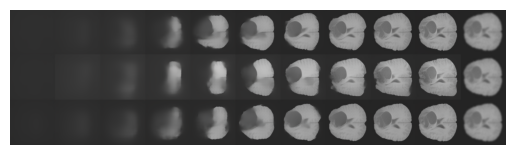

gt   1: tensor([2226,  714, 3629, 3969, 3275, 3504, 1638,  886, 3575, 1933],
       device='cuda:0')


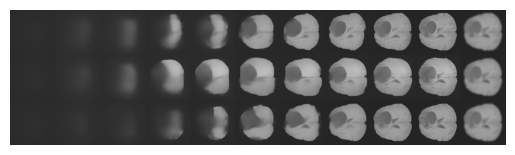

gt   2: tensor([3985,  714, 3026, 3053, 3275, 1748, 2215, 1033,  764, 1871],
       device='cuda:0')


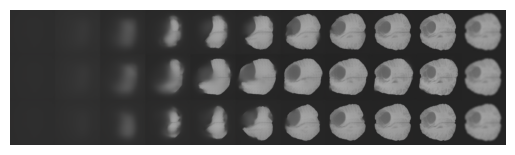

gt   3: tensor([3985,  714,  645, 3053,  673, 1748, 2819, 1012, 3032, 1871],
       device='cuda:0')


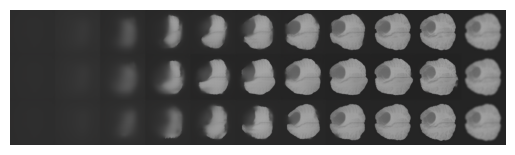

gt   4: tensor([3985,  714,  479, 2493, 1568, 2505, 2207,  998, 1819, 2221],
       device='cuda:0')


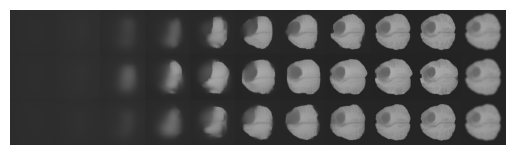

gt   5: tensor([ 627, 4027,  767, 4027, 3985, 2075, 3963,  575, 2897,  931],
       device='cuda:0')


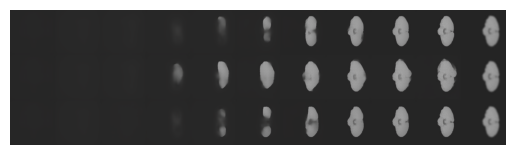

gt   6: tensor([ 627,  673, 3985, 2407, 3985, 3192,  308, 1791, 4042, 2301],
       device='cuda:0')


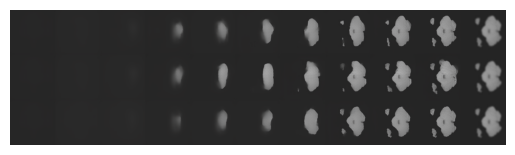

gt   7: tensor([ 627, 1977, 3689, 3791, 1187, 1658,  377, 2937, 4058, 2301],
       device='cuda:0')


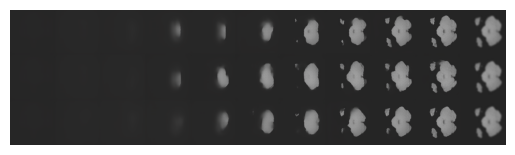

gt   8: tensor([3985, 2910, 2499,  475, 3377, 3383, 3187, 1452, 3551, 3246],
       device='cuda:0')


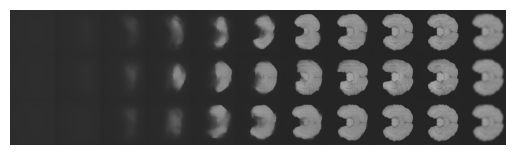

gt   9: tensor([3689, 1421,  767, 3460, 3983,  608, 2663, 3839,  972, 3767],
       device='cuda:0')


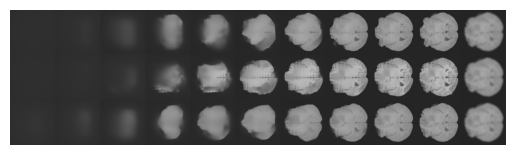

gt   10: tensor([3689, 2688,  767, 2741,  933, 1165,  393, 3146, 1176, 3890],
       device='cuda:0')


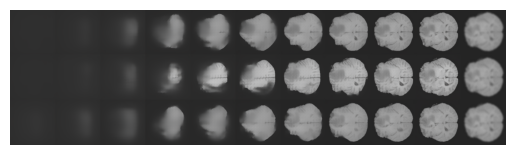

In [6]:


for idx, (inp_B3HW_low, inp_B3HW_super) in enumerate(ld_val):
    
    
    inp_B3HW_low = inp_B3HW_low.to(dist.get_device(), non_blocking=True)
    inp_B3HW_super = inp_B3HW_super.to(dist.get_device(), non_blocking=True)
    B, V = inp_B3HW_low.shape[0], vae.vocab_size
    
    low_f = vae.img_to_f(inp_B3HW_low)
    low_f = low_f.permute(0, 2, 3, 1)
    low_f = low_f.reshape(B, low_f.shape[1] * low_f.shape[2], low_f.shape[3])# B=36
    
    
    gt_idx_Bl_super= vae.img_to_idxBl(inp_B3HW_super)
    gt_BL_super = torch.cat(gt_idx_Bl_super, dim=1)
    x_BLCv_wo_first_l_super= vae.quantize.idxBl_to_var_input(gt_idx_Bl_super)
    
    # [3,679,32]
    lowLen, lowC = low_f.shape[1], low_f.shape[2]
    
    lens = torch.tensor([lowLen] * B,dtype=torch.int32).to(device=x_BLCv_wo_first_l_super.device)  # 每个句子的 token 长度
    
    low_f = low_f.reshape( -1, lowC)
    
    max_seqlen_k = lens.max().to(device=x_BLCv_wo_first_l_super.device)  # 5
    cu_seqlens_k = torch.cumsum(torch.cat([torch.tensor([0],dtype=torch.int32).to(device=x_BLCv_wo_first_l_super.device), lens]), dim=0).to(device=x_BLCv_wo_first_l_super.device).to(dtype = torch.int32)
    label_B_or_BLT = (low_f, lens, cu_seqlens_k, max_seqlen_k)
    
    
    h_div_w = inp_B3HW_low.shape[-2] / inp_B3HW_low.shape[-1]
    T = 1 if inp_B3HW_low.dim() == 4 else inp_B3HW_low.shape[2]
    h_div_w_templates = np.array(list(dynamic_resolution_h_w.keys()))
    h_div_w_template = h_div_w_templates[np.argmin(np.abs(h_div_w-h_div_w_templates))]
    scale_schedule = dynamic_resolution_h_w[h_div_w_template]["1M"]['scales']
    scale_schedule = [ (min(t, T//4+1), h, w) for (t,h, w) in scale_schedule]
    
    
    idx_predict = []
    for si,pn in enumerate(patch_nums):
        idx_predict.append(torch.zeros(B,pn*pn,dtype=torch.int64).to(device=x_BLCv_wo_first_l_super.device))
    
    Cul_L = 0
    for si, pn in enumerate(patch_nums):
        num_pn = pn*pn
        # if si<=1:
        #     print("idx_predict:",idx_predict[:si])
        temp_BLC = vae.quantize.idxBl_to_var_input(idx_predict)
        # if si<=1:
        #     print("temp_BLC",temp_BLC[:,:9,:3])
        logits_BLV = srvar(label_B_or_BLT, temp_BLC ,scale_schedule,cfg_infer=True)
        value_train, idx_test = torch.max(logits_BLV.data, dim=-1)

        logits_BLV_soft = torch.nn.functional.softmax(logits_BLV, dim=-1)
        top_values, top_indices = torch.topk(logits_BLV_soft, k=min(5, logits_BLV.shape[-1]), dim=-1)
        # if si<=1:
        #     print("top_values:",top_values[:,Cul_L:Cul_L+num_pn])
        
        idx_predict[si] = idx_test[:,Cul_L:Cul_L+num_pn].reshape(B,num_pn)
        Cul_L = Cul_L + num_pn
        
    idx_Bl_list = idx_predict
    idx_predict = torch.cat(idx_predict,dim=1)

    # print(x_BLCv_wo_first_l_super[:,:15,:3])
    logits_BLV = srvar(label_B_or_BLT, x_BLCv_wo_first_l_super,scale_schedule,cfg_infer=True)
    idx_train = logits_BLV.data.argmax(dim=-1)

    show = 1+9
    # print(f"test {idx}:",idx_predict[0][:show])
    # print(f"train{idx}:",idx_train[0][:show])
    print(f"gt   {idx}:",gt_BL_super[0][:show])
    
    # print("acc_train:",(idx_train == gt_BL_super).sum().item() / (B*gt_BL_super.shape[1]))
    # print("acc_list:",(idx_predict == gt_BL_super).sum().item() / (B*gt_BL_super.shape[1]))
    # print("train_list:",(idx_predict == idx_train).sum().item() / (B*gt_BL_super.shape[1]))


    nup_test = vae.idxBl_to_img(idx_Bl_list, same_shape=True, last_one=False)
    nup_gt = vae.idxBl_to_img(gt_idx_Bl_super, same_shape=True, last_one=False)
    start_idx = 0
    result_train = []
    for path_num in patch_nums:
        end_idx = start_idx + path_num ** 2
        result_train.append(idx_train[:, start_idx:end_idx])  
        start_idx = end_idx  
    nup_train = vae.idxBl_to_img(result_train, same_shape=True, last_one=False)
    
    def process_image(x):
        """处理单张图片"""    
        x = x[0].detach().cpu().permute(1, 2, 0).numpy()  # 转换为 HWC 格式的 numpy 数组
        x = (x * 0.5 + 0.5) * 255  # 反归一化并缩放到 [0, 255]
        x = x.astype(np.uint8)  # 转换为 uint8
        return x

    def concatenate_images(images, axis):
        """沿指定轴拼接图片"""
        return np.concatenate(images, axis=axis)
    
    train_combined = concatenate_images([process_image(x) for x in nup_train], axis=1)  # 左右连接
    test_combined = concatenate_images([process_image(x) for x in nup_test], axis=1)   # 左右连接
    gt_combined = concatenate_images([process_image(x) for x in nup_gt], axis=1)      # 左右连接
    
    inp_B3HW_low = process_image(inp_B3HW_low)
    
    train_combined = concatenate_images([train_combined, inp_B3HW_low],axis=1)
    test_combined = concatenate_images([test_combined, inp_B3HW_low],axis=1)
    gt_combined = concatenate_images([gt_combined, inp_B3HW_low],axis=1)
    
    
    
    # 将三个结果上下连接
    final_image = concatenate_images([test_combined, train_combined , gt_combined], axis=0)  # 上下连接
    # Image.fromarray(final_image)
    plt.imshow(final_image)
    plt.axis('off')  # 可选，关闭坐标轴
    plt.show()
    if tot > 0 and idx >= tot:
        break

In [7]:
print(vae.quantize.embedding(torch.tensor(816).cuda()))
print(vae.quantize.embedding(torch.tensor(627).cuda()))

tensor([-0.0419,  0.0659, -0.0234,  0.0072, -0.0113,  0.0216,  0.0172, -0.0002,
        -0.0411,  0.0418, -0.0124, -0.0238,  0.0121,  0.0230,  0.0019,  0.0302,
        -0.0293,  0.0057, -0.0410,  0.0622, -0.0157,  0.0720, -0.0678,  0.0503,
        -0.0321,  0.0418, -0.0329, -0.1229, -0.0141,  0.0058, -0.0165, -0.0378],
       device='cuda:0')
tensor([-0.0550,  0.0161, -0.0162, -0.0130, -0.0527, -0.0154, -0.0111, -0.0166,
         0.0963,  0.0255,  0.0186,  0.0109,  0.0695,  0.0153, -0.0755,  0.0102,
        -0.0030, -0.0140, -0.1334,  0.0844, -0.0641,  0.0167, -0.0175,  0.0643,
        -0.1319,  0.0139, -0.0269,  0.0092,  0.0437,  0.0665,  0.0523,  0.0233],
       device='cuda:0')


In [16]:
for idx, (inp_B3HW_low, inp_B3HW_super) in enumerate(ld_train):
    
    
    inp_B3HW_low = inp_B3HW_low.to(dist.get_device(), non_blocking=True)
    inp_B3HW_super = inp_B3HW_super.to(dist.get_device(), non_blocking=True)
    
    B, V = inp_B3HW_low.shape[0], vae.vocab_size
    f = vae.quant_conv(vae.encoder(inp_B3HW_super))
    print(f[0,:,0,0])

tensor([-0.6939,  0.0711,  0.2335, -0.1550,  0.2968,  0.1741,  0.3755, -0.3513,
         0.5496,  0.2655, -0.1254,  0.0100,  0.1457, -0.2015, -0.0719, -0.1114,
         0.2614, -0.2718,  0.5037,  0.3367, -0.0623,  0.6009, -0.2949, -0.5092,
         0.4166,  0.1007, -0.0073,  0.2297,  0.1392,  0.6007, -0.2071, -0.0141],
       device='cuda:0')
tensor([-0.3040,  0.1002, -0.2144,  0.1399, -0.1460, -0.0424,  0.3990, -0.0385,
         0.3993,  0.1915, -0.1660, -0.0910, -0.0105, -0.0156,  0.4593,  0.3253,
         0.4480,  0.1531, -0.2262,  0.0919, -0.0797, -0.1270, -0.3318, -0.4087,
         0.1546, -0.1497,  0.4444,  0.1248, -0.0915, -0.1540, -0.1609, -0.1649],
       device='cuda:0')
tensor([ 0.0485,  0.1321, -0.0909,  0.2471, -0.1806,  0.1879,  0.3734, -0.1201,
         0.0099,  0.0575, -0.1419, -0.1294, -0.1756,  0.3709,  0.4801,  0.1833,
         0.2373,  0.2575, -0.2251,  0.1395, -0.3578, -0.0301, -0.0649, -0.1239,
         0.1413,  0.0521, -0.1288,  0.0184,  0.2153, -0.4461, -0.2498,

KeyboardInterrupt: 

[tensor([[3745]], device='cuda:0'), tensor([[1281, 1341, 1341, 1341]], device='cuda:0')]


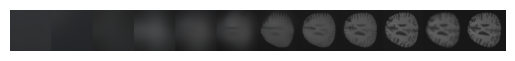

[tensor([[191]], device='cuda:0'), tensor([[2655, 3558, 2930, 1319]], device='cuda:0')]


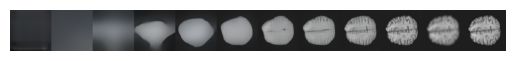

[tensor([[191]], device='cuda:0'), tensor([[ 965, 3845, 2817, 3543]], device='cuda:0')]


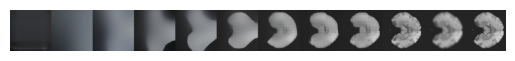

[tensor([[1341]], device='cuda:0'), tensor([[ 191, 3804,  687, 3804]], device='cuda:0')]


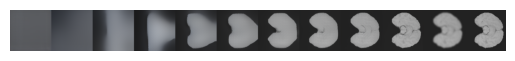

[tensor([[2640]], device='cuda:0'), tensor([[2442, 2976, 2438, 3849]], device='cuda:0')]


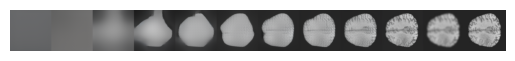

[tensor([[2640]], device='cuda:0'), tensor([[1485, 3849, 3849, 2184]], device='cuda:0')]


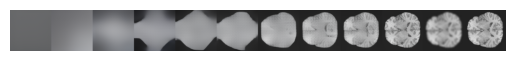

[tensor([[3745]], device='cuda:0'), tensor([[1341,   29, 1341, 3543]], device='cuda:0')]


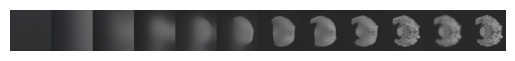

[tensor([[2640]], device='cuda:0'), tensor([[ 736, 3921, 2921, 3520]], device='cuda:0')]


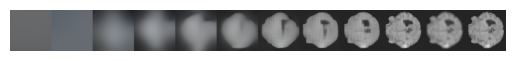

[tensor([[1779]], device='cuda:0'), tensor([[2655, 2334,  687,  474]], device='cuda:0')]


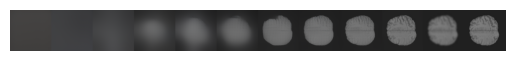

[tensor([[1779]], device='cuda:0'), tensor([[ 474,  474,  687, 3543]], device='cuda:0')]


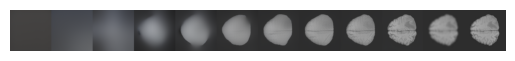

[tensor([[1779]], device='cuda:0'), tensor([[2828, 1125, 2640, 2655]], device='cuda:0')]


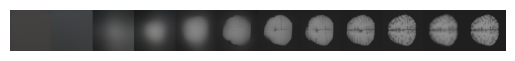

In [ ]:

for idx, (inp_B3HW_low, inp_B3HW_super) in enumerate(ld_train):
    
    
    inp_B3HW_low = inp_B3HW_low.to(dist.get_device(), non_blocking=True)
    inp_B3HW_super = inp_B3HW_super.to(dist.get_device(), non_blocking=True)
    
    B, V = inp_B3HW_low.shape[0], vae.vocab_size
    
    low_f = vae.img_to_f(inp_B3HW_low)
    low_f = low_f.permute(0, 2, 3, 1)
    low_f = low_f.reshape(B, low_f.shape[1] * low_f.shape[2], low_f.shape[3])# B=36
    
    
    gt_idx_Bl_super= vae.img_to_idxBl(inp_B3HW_super)
    gt_BL_super = torch.cat(gt_idx_Bl_super, dim=1)
    x_BLCv_wo_first_l_super= vae.quantize.idxBl_to_var_input(gt_idx_Bl_super)
    
    # [3,679,32]
    lowLen, lowC = low_f.shape[1], low_f.shape[2]
    
    lens = torch.tensor([lowLen] * B,dtype=torch.int32).to(device=x_BLCv_wo_first_l_super.device)  # 每个句子的 token 长度
    
    low_f = low_f.reshape( -1, lowC)
    
    max_seqlen_k = lens.max().to(device=x_BLCv_wo_first_l_super.device)  # 5
    cu_seqlens_k = torch.cumsum(torch.cat([torch.tensor([0],dtype=torch.int32).to(device=x_BLCv_wo_first_l_super.device), lens]), dim=0).to(device=x_BLCv_wo_first_l_super.device).to(dtype = torch.int32)
    label_B_or_BLT = (low_f, lens, cu_seqlens_k, max_seqlen_k)
    
    
    h_div_w = inp_B3HW_low.shape[-2] / inp_B3HW_low.shape[-1]
    T = 1 if inp_B3HW_low.dim() == 4 else inp_B3HW_low.shape[2]
    h_div_w_templates = np.array(list(dynamic_resolution_h_w.keys()))
    h_div_w_template = h_div_w_templates[np.argmin(np.abs(h_div_w-h_div_w_templates))]
    scale_schedule = dynamic_resolution_h_w[h_div_w_template]["1M"]['scales']
    scale_schedule = [ (min(t, T//4+1), h, w) for (t,h, w) in scale_schedule]

    nup_gt = vae.idxBl_to_img(gt_idx_Bl_super, same_shape=True, last_one=False)
    
    print(gt_idx_Bl_super[:2])
    
    def process_image(x):
        """处理单张图片"""    
        x = x[0].detach().cpu().permute(1, 2, 0).numpy()  # 转换为 HWC 格式的 numpy 数组
        x = (x * 0.5 + 0.5) * 255  # 反归一化并缩放到 [0, 255]
        x = x.astype(np.uint8)  # 转换为 uint8
        return x

    def concatenate_images(images, axis):
        """沿指定轴拼接图片"""
        return np.concatenate(images, axis=axis)
    

    gt_combined = concatenate_images([process_image(x) for x in nup_gt], axis=1)      # 左右连接
    inp_B3HW_low = process_image(inp_B3HW_low)
    inp_B3HW_super = process_image(inp_B3HW_super)
    gt_combined = concatenate_images([gt_combined, inp_B3HW_low,inp_B3HW_super],axis=1)

    # Image.fromarray(final_image)
    plt.imshow(gt_combined)
    plt.axis('off')  # 可选，关闭坐标轴
    plt.show()
    if tot > 0 and idx >= tot:
        break

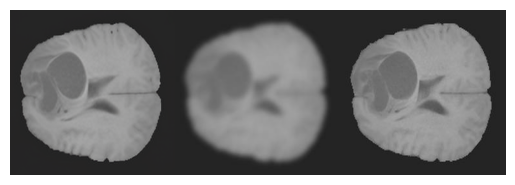

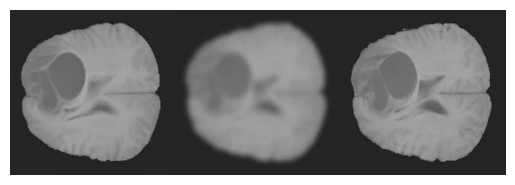

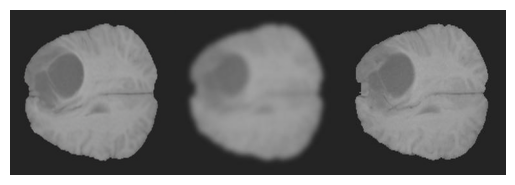

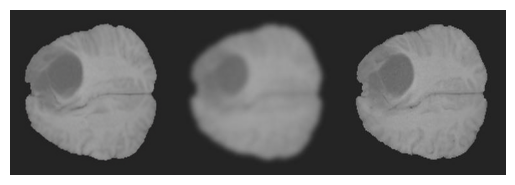

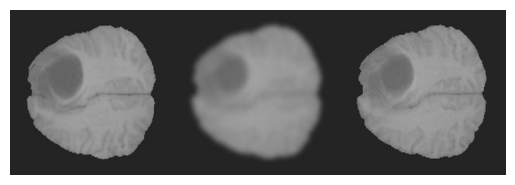

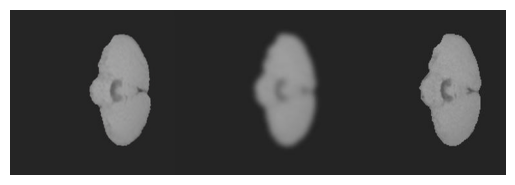

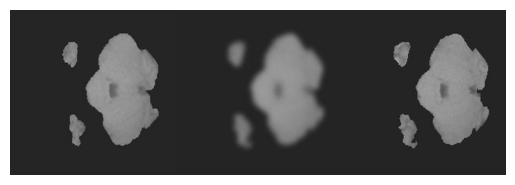

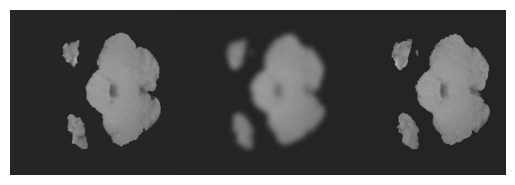

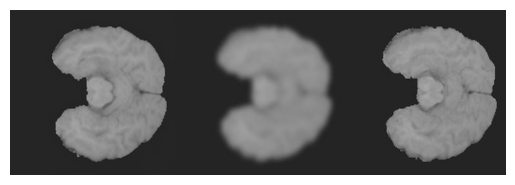

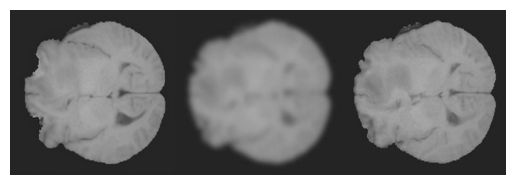

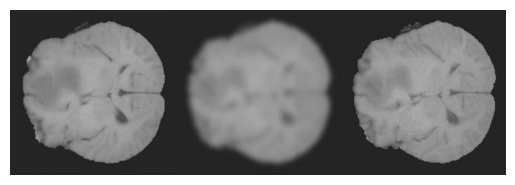

In [7]:


for idx, (inp_B3HW_low, inp_B3HW_super) in enumerate(ld_val):
    
    
    inp_B3HW_low = inp_B3HW_low.to(dist.get_device(), non_blocking=True)
    inp_B3HW_super = inp_B3HW_super.to(dist.get_device(), non_blocking=True)
    B, V = inp_B3HW_low.shape[0], vae.vocab_size
    
    low_f = vae.img_to_f(inp_B3HW_low)
    low_f = low_f.permute(0, 2, 3, 1)
    low_f = low_f.reshape(B, low_f.shape[1] * low_f.shape[2], low_f.shape[3])# B=36
    
    
    gt_idx_Bl_super= vae.img_to_idxBl(inp_B3HW_super)
    gt_BL_super = torch.cat(gt_idx_Bl_super, dim=1)
    x_BLCv_wo_first_l_super= vae.quantize.idxBl_to_var_input(gt_idx_Bl_super)
    
    # [3,679,32]
    lowLen, lowC = low_f.shape[1], low_f.shape[2]
    
    lens = torch.tensor([lowLen] * B,dtype=torch.int32).to(device=x_BLCv_wo_first_l_super.device)  # 每个句子的 token 长度
    
    low_f = low_f.reshape( -1, lowC)
    
    max_seqlen_k = lens.max().to(device=x_BLCv_wo_first_l_super.device)  # 5
    cu_seqlens_k = torch.cumsum(torch.cat([torch.tensor([0],dtype=torch.int32).to(device=x_BLCv_wo_first_l_super.device), lens]), dim=0).to(device=x_BLCv_wo_first_l_super.device).to(dtype = torch.int32)
    label_B_or_BLT = (low_f, lens, cu_seqlens_k, max_seqlen_k)
    
    
    h_div_w = inp_B3HW_low.shape[-2] / inp_B3HW_low.shape[-1]
    T = 1 if inp_B3HW_low.dim() == 4 else inp_B3HW_low.shape[2]
    h_div_w_templates = np.array(list(dynamic_resolution_h_w.keys()))
    h_div_w_template = h_div_w_templates[np.argmin(np.abs(h_div_w-h_div_w_templates))]
    scale_schedule = dynamic_resolution_h_w[h_div_w_template]["1M"]['scales']
    scale_schedule = [ (min(t, T//4+1), h, w) for (t,h, w) in scale_schedule]
    
    
    idx_predict = []
    for si,pn in enumerate(patch_nums):
        idx_predict.append(torch.zeros(B,pn*pn,dtype=torch.int64).to(device=x_BLCv_wo_first_l_super.device))
    
    Cul_L = 0
    for si, pn in enumerate(patch_nums):
        num_pn = pn*pn
        # if si<=1:
        #     print("idx_predict:",idx_predict[:si])
        temp_BLC = vae.quantize.idxBl_to_var_input(idx_predict)
        # if si<=1:
        #     print("temp_BLC",temp_BLC[:,:9,:3])
        logits_BLV = srvar(label_B_or_BLT, temp_BLC ,scale_schedule,cfg_infer=True)
        value_train, idx_test = torch.max(logits_BLV.data, dim=-1)

        logits_BLV_soft = torch.nn.functional.softmax(logits_BLV, dim=-1)
        top_values, top_indices = torch.topk(logits_BLV_soft, k=min(5, logits_BLV.shape[-1]), dim=-1)
        # if si<=1:
        #     print("top_values:",top_values[:,Cul_L:Cul_L+num_pn])
        
        idx_predict[si] = idx_test[:,Cul_L:Cul_L+num_pn].reshape(B,num_pn)
        Cul_L = Cul_L + num_pn
        
    idx_Bl_list = idx_predict
    idx_predict = torch.cat(idx_predict,dim=1)

    nup_test = vae.idxBl_to_img(idx_Bl_list, same_shape=True, last_one=False)
    
    def process_image(x):
        """处理单张图片"""    
        x = x[0].detach().cpu().permute(1, 2, 0).numpy()  # 转换为 HWC 格式的 numpy 数组
        x = (x * 0.5 + 0.5) * 255  # 反归一化并缩放到 [0, 255]
        x = x.astype(np.uint8)  # 转换为 uint8
        return x

    def concatenate_images(images, axis):
        """沿指定轴拼接图片"""
        return np.concatenate(images, axis=axis)
    
    test_combined = [process_image(x) for x in nup_test][-1]  # 左右连接
    inp_B3HW_low = process_image(inp_B3HW_low)    
    inp_B3HW_super = process_image(inp_B3HW_super)
    test_combined = concatenate_images([test_combined, inp_B3HW_low,inp_B3HW_super],axis=1)
    
    plt.imshow(test_combined)
    plt.axis('off')  # 可选，关闭坐标轴
    plt.show()
    if tot > 0 and idx >= tot:
        break